# Day 014 · R² 与策略评估
**R-squared in Strategies** · 阶段 P1 · 量化基础

> R² 是评价模型解释力的量化指标。如果说 Day 9 的贝塔告诉你'股票跟大盘走的方向有多陡',R² 告诉你'这条棍子贴得多紧'。两个值合起来才是完整画像。本节讲清五件事:① R² 的几何直觉(在散点图里它就是棍子贴近度);② 公式 1 - SS_res/SS_tot 怎么算 + 物理含义;③ 高 R² 不一定是好事——主动基金 R² 大于零点九五就是 closet indexing 抱指数躺平;④ Adjusted R² 防止你靠加垃圾变量提分;⑤ in-sample R² vs out-of-sample R² 是评估过拟合最直接的工具,落差大于一半视为警告。**学完你能用三个数字(贝塔 + R² + 调整 R²)给任何一只股票或任何一个策略打出体检报告**,看出它是真的 alpha 还是假的独立、是真本事还是抱指数。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 16 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解 R² 的几何直觉 — 棍子贴散点的紧密度,以及 R² 在零到一区间的物理含义
- 掌握 R² = 1 - SS_res/SS_tot 的计算和'解释方差占比'的核心解读
- 区分'高贝塔 + 高 R²'(跟随风格)、'高贝塔 + 低 R²'(独立)、'低贝塔 + 低 R²'(防御)三种股票画像
- 知道为什么 Adjusted R² 比普通 R² 更可靠 — 加垃圾变量也能把 R² 推上去
- 掌握 in-sample R² vs out-of-sample R² 双值报告纪律 — 出样本 R² 跌幅大于一半视为过拟合警告
- 识别'主动基金 R² 大于零点九五'是 closet indexing 抱指数,不是真 alpha

## 历史背景:Cremers 与 Petajisto 二零零九揭穿 closet indexing — 一篇论文让三成主动基金现形

二零零九年耶鲁大学的 Martijn Cremers 和 Antti Petajisto 发表了一篇震动整个共同基金界的论文 — 《How Active Is Your Fund Manager? A New Measure That Predicts Performance》。他们提出了一个简单到令人尴尬的指标:Active Share — 看一只主动基金的持仓和它对标指数有多大重叠。R² 跟这个故事密切相关:如果你把主动基金的日收益对沪深三百或者标普五百做线性回归,R² 越高说明它越像指数。

他们查了一九八零到二零零三年所有美国主动股票基金,发现三成以上的所谓'主动'基金 R² 大于零点九五(意思是收益的百分之九十五能用指数解释),Active Share 只有百分之二十到四十(意思是它实际买的就是指数成分股)。这些基金收着百分之一点五的主动管理费,实际只是抱住指数躺平 — 学术界把这叫 closet indexing,衣柜里的指数基金。投资者付主动费用却拿被动产品。论文一发,SEC 开始监管,欧洲也开始调查,数千只基金被迫调整持仓或者降费。

中国基金界二零二零到二零二一年也发生过完全一样的事 — 千亿级'主动'基金清一色重仓茅台、五粮液、海天味业、宁德时代、隆基绿能这一篮子茅指数和宁组合,跟沪深三百和创业板指数的 R² 在零点八五以上。那两年看似主动管理,实际是高费率版的指数 ETF。二零二二年指数回调三成五,这些基金净值同步腰斩,投资者才意识到费用全白付。

R² 这个看起来很学术的指标,在现实里是揭穿伪装的探照灯。**散户买基金第一件事:看它跟指数 R² 是多少**。大于零点九五立刻换 ETF,中间段才考虑费率是否值得。

**关键人物:**
- Martijn Cremers 与 Antti Petajisto(二零零九 Active Share 论文 + R² 揭穿 closet indexing)
- Karl Pearson(一九零三年提出相关系数的平方就是 R² 雏形)
- Eugene Fama 与 Kenneth French(三因子模型对个股 R² 平均零点七到零点九)
- Andrew Lo(MIT Sloan,大量 R² 与 alpha 关系研究)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. R² 的几何直觉:棍子贴散点贴得有多紧

Day 9 我们讲了贝塔 — 用最小二乘法拟合一条棍子,棍子的斜率就是贝塔。今天讲第二个量:这条棍子贴得有多紧。
**直觉**:在散点图里画一条最佳拟合线,然后量每个点离这条线的垂直距离(叫残差)。所有残差越小,意味着棍子贴得越紧,R² 越高。
- R² 等于一:所有点都在棍子上,完美预测。现实中几乎不可能,数据完全无噪声才行。
- R² 等于零:棍子还不如样本均值有用。模型没解释任何东西。
- R² 等于零点八五:模型解释了百分之八十五的波动,百分之十五是无法解释的'噪声'(叫 idiosyncratic 个股特性,或黑天鹅,或测量误差)
**金融场景**:沪深三百 ETF 对沪深三百指数 R² 接近一(几乎完美);平安银行对沪深三百 R² 大约零点六(银行整体跟金融板块走);紫金矿业对沪深三百 R² 大约零点三(它跟铜价、黄金价更相关);长江电力对沪深三百 R² 大约零点二(防御股,自己一个节奏)。

```
R² ∈ [0, 1]    越接近 1 → 棍子贴得越紧 → 模型解释力越强
```

> **举例:** 你给沪深三百成分股(三百只)分别对沪深三百指数做回归,R² 中位数大约零点六。意思是平均一只股票百分之六十的波动能用大盘解释,百分之四十是它自己的故事。这就是为什么单一 ETF 风险还不够分散 — 跟大盘相关的部分可以一起跌。


### 2. 公式背后的直觉:R² = 1 - 残差方差 / 总方差

R² 公式三步走:

- **第一步:总方差 SS_tot**:= 把所有 y 减去 y 的均值,平方后加总。意思是'数据本身的总散开程度'。
- **第二步:残差方差 SS_res**:= 把所有 实际 y 减去 预测 y 的差,平方后加总。意思是'模型预测后还剩多少波动没解释'。
- **第三步:R² = 1 - SS_res / SS_tot**
- **直觉一句话**:你的模型把数据的波动消除了多少。如果消除了百分之八十(SS_res 只剩 SS_tot 的百分之二十),R² 等于零点八。
- **重要等价**:R² 也等于'拟合 y 与实际 y 的皮尔逊相关系数的平方'。比如某只股票对大盘相关系数是零点九二,那 R² = 零点九二的平方 = 零点八四六四。这就是为什么 R² 总是非负的(平方),并且自动归一化到零到一(因为相关系数本身在负一到正一)。

```
R² = 1 - SS_res / SS_tot = 1 - Σ(y - ŷ)² / Σ(y - ȳ)²    等价于    corr(y, ŷ)²
```

> **举例:** 假设某股票回归到大盘:总方差 SS_tot 等于零点零一,模型预测后残差方差 SS_res 等于零点零零三五。R² 等于 1 - 零点零零三五 / 零点零一 = 零点六五。意思是模型解释了百分之六十五的股价波动,百分之三十五是模型外的(个股特异性)。


### 3. Adjusted R²:多变量回归的诚实者

普通 R² 有个致命缺陷:**你每加一个变量,R² 必涨**(数学性质)。哪怕你加的是完全随机的噪声,R² 也会涨,虽然涨得很少。这就给'靠加变量造假'开了门。

- **Adjusted R²**:(中文叫调整后 R²)加了惩罚项:多一个变量,Adj R² 不一定涨,如果新变量没真正贡献,Adj R² 反而会降。
- **公式**:Adj R² = 1 减去 (1-R²) 乘以 (n-1) 除以 (n-k-1),其中 n 是样本量,k 是自变量个数。
- **实战意义**:任何多因子模型必报 Adj R²。

- 三因子 Fama-French (k=3),普通 R² 对个股大约零点七五,Adj R² 大约零点七四五(几乎一致)
- 五因子 (k=5)、十因子 (k=10),如果新加的不是真因子,Adj R² 会先涨后跌甚至直接下降

- **散户判断**:看到任何研究材料里说'我加了二十个特征 R² 涨到零点九二' → 立即问'Adj R² 是多少'。如果对方支吾或没算,说明这是垃圾变量堆出来的 R²。

```
Adj R² = 1 - (1 - R²) × (n - 1) / (n - k - 1)    k = 自变量数
```

> **举例:** 你做多因子选股,n 等于一千天:用一个因子 R² 等于零点一零,Adj R² 大约零点零九九。加到五个因子 R² 等于零点一八,Adj R² 大约零点一七六。再加到三十个因子 R² 等于零点二零,Adj R² 只有零点一七六 — 后二十五个因子总共贡献为零,说明它们是垃圾。


### 4. in-sample R² vs out-of-sample R²(过拟合检测器,本节最重要)

普通 R² 都是 in-sample(中文叫样本内)— 用全部数据拟合,然后看模型对同一份数据的解释力。这个数字几乎一定好看。
**Out-of-sample R²(样本外 R²)** 是真正的金标准:用一段历史数据拟合模型,然后用'**模型从未见过**'的另一段数据测它的解释力。
**计算流程**(三步):
- 第一步:in-sample(前两年数据,叫训练集),拟合 → R²_in 算出来比如等于零点六五
- 第二步:out-of-sample(后一年,叫测试集),用上面拟合的模型去预测,算 R²_out
- 第三步:对比。如果 R²_out 跌到零点三零 → 已经过拟合了;如果 R²_out 接近 R²_in → 模型稳健
**经验规则**:R²_out 除以 R²_in 小于零点五 ⇒ 过拟合警告;大于零点七 ⇒ 优秀。
**为什么这件事散户最常忽略**:in-sample 数字漂亮,卖单容易,大家就只报 in-sample。各种私募和雪球大 V 晒回测,百分之九十九都是 in-sample R²。**真正的纪律**:任何模型上线前必须报 in-sample 和 out-of-sample 双值,且差距小于一半。

```
R²_out = 1 - SS_res(test set) / SS_tot(test set)    必须用拟合阶段未见过的数据
```

> **举例:** 你做了一个二十因子选股模型,二零一八到二零二二年数据训练 R²_in 等于零点三零,二零二三到二零二四年测试 R²_out 等于零点零五。落差百分之八十三,严重过拟合。砍到五个因子重训,R²_in 等于零点一八,R²_out 等于零点一四,落差百分之二十二,稳健可上线。


### 5. 高 R² 不一定是好事 — closet indexing 警钟

对个股做回归 R² 越高越能解释,这是好事。但对**主动管理产品**做回归,R² 越高反而是危险信号。
**主动基金的 R² 谱**:
- R² 小于零点五:深度主动管理(选股、择时、行业偏离明显),费率合理
- 零点五到零点八五:中度主动 — 大多数中国主动基金落在这里
- 零点八五到零点九五:轻度主动 — 已经接近 closet indexing
- 大于零点九五:**closet indexing(衣柜里的指数基金)** — 主动费率被动业绩,投资者亏的是费用差
**为什么基金经理愿意 closet?**因为偏离指数等于跟踪误差大,等于业绩有可能跑输大盘,等于失业。抱住指数加上收百分之一点五的费 = 旱涝保收。
**散户检测方法**:
1. 拉基金近两百五十天日收益,对沪深三百或者中证八百做线性回归
2. 看 R² — 如果大于零点九零警告,大于零点九五立即换 ETF
3. 看 Active Share(持仓非指数权重之和的一半)— Cremers 和 Petajisto 标准小于百分之六十就是 closet
**中国二零二零到二零二一年茅指数和宁组合现象** — 多只千亿主动基金互相抱团 R² 在零点八五以上,本质上变成了高费率茅指数 ETF。

```
Active Share = 0.5 × Σ |w_fund - w_index|    < 60% 视为 closet indexing
```

> **举例:** 某千亿主动基金二零二零到二零二一年对沪深三百 R² 等于零点九二,对茅指数 R² 等于零点九六,Active Share 百分之三十五。结论:这不是主动基金,是高费茅指数 ETF。二零二二年茅指数下跌百分之三十五,基金净值下跌百分之三十三,管理费照收百分之一点五。


## 实操:R² 三视角:个股画像 + 加因子 Adj R² 检验 + in/out 过拟合检测

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


[*********************100%***********************]  5 of 5 completed


数据样本量:723 个交易日

=== 三种股票画像 · 单因子回归 ===
  股票     β    R²   画像
平安银行 0.748 0.409  半独立
紫金矿业 0.988 0.241 基本独立
长江电力 0.119 0.021 基本独立
招商银行 0.669 0.313  半独立

=== Adj R² 揭穿垃圾因子 ===
         模型     R²  Adj R²
   只用大盘 (1) 0.4086  0.4078
  +1 噪声 (2) 0.4089  0.4073
  +5 噪声 (6) 0.4107  0.4058
+20 噪声 (21) 0.4259  0.4087
R² 一直涨 / Adj R² 加垃圾后停涨甚至降 → Adj R² 是诚实者

=== in/out R² 过拟合检测 ===
         模型  R²_in  R²_out   落差%
   A · 只用大盘 0.5206 -0.1916 136.8
B · 加 24 垃圾 0.5316 -0.1757 133.1
A 模型 R²_in/R²_out 接近 → 稳健;B 模型 R²_in 高 R²_out 暴跌 → 过拟合

✓ 图已保存到 day014_r2_eval.png


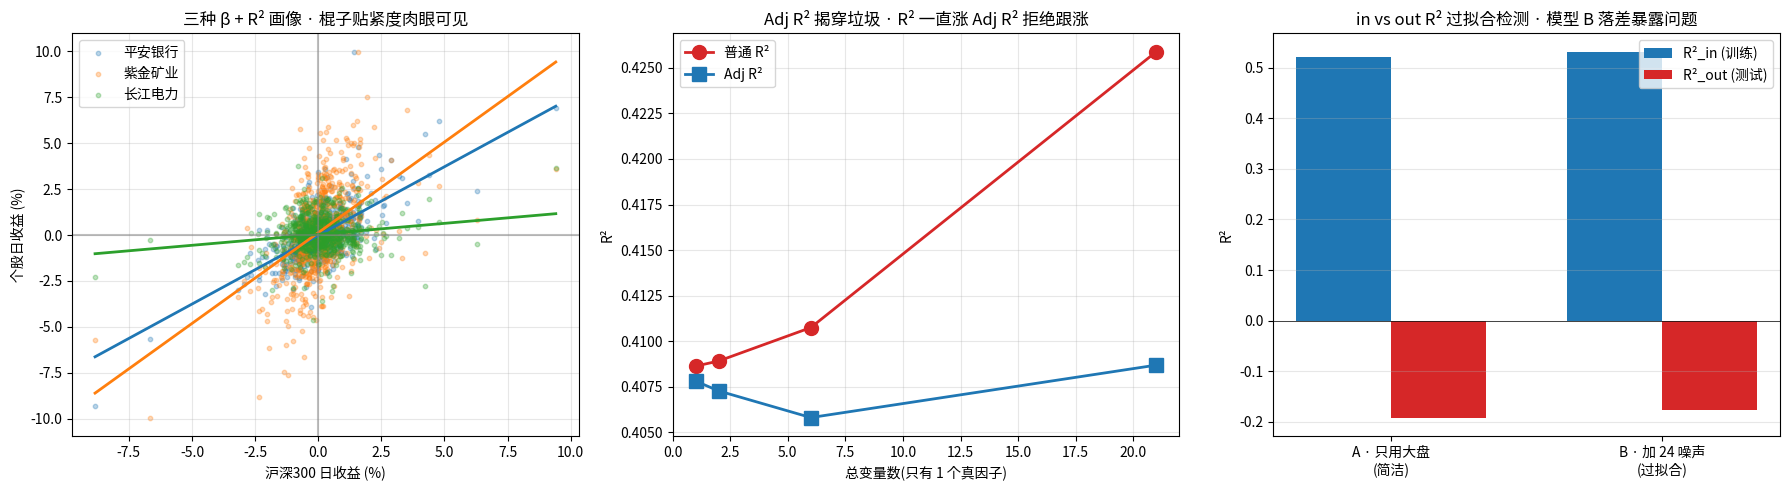

In [2]:
# day_014_r2_strategy_eval.py — R² 在策略评估的三个真实场景
import numpy as np, pandas as pd, yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ============ 1. 拉 4 只标的 + 沪深300 三年数据 ============
tickers = {
    '沪深300':  '510300.SS',
    '平安银行': '000001.SZ',  # 高 β + 高 R²(跟大盘)
    '紫金矿业': '601899.SS',  # 高 β + 中 R²(商品周期)
    '长江电力': '600900.SS',  # 低 β + 低 R²(防御独立)
    '招商银行': '600036.SS',  # 比较组
}
raw = yf.download(list(tickers.values()), period='3y', auto_adjust=True)['Close']
# yfinance 字母序返回 → 用 dict 显式按 ticker 名字映射,避免列错位
raw = pd.DataFrame({name: raw[ticker] for name, ticker in tickers.items()})
ret = raw.pct_change().dropna()
mkt = ret['沪深300']
print(f'数据样本量:{len(ret)} 个交易日')

# ============ 2. 三只股票对沪深300 单因子回归 — 算 β 和 R² ============
print('\n=== 三种股票画像 · 单因子回归 ===')
rows = []
for name in ['平安银行','紫金矿业','长江电力','招商银行']:
    y = ret[name].values.reshape(-1, 1)
    X = mkt.values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    beta = float(model.coef_[0][0])
    r2 = float(model.score(X, y))
    pic = '跟随大盘' if r2 > 0.5 else ('半独立' if r2 > 0.25 else '基本独立')
    rows.append({'股票': name, 'β': round(beta, 3), 'R²': round(r2, 3), '画像': pic})
df1 = pd.DataFrame(rows)
print(df1.to_string(index=False))

# ============ 3. Adjusted R² 演示 — 加垃圾变量怎么暴露 ============
print('\n=== Adj R² 揭穿垃圾因子 ===')
np.random.seed(42)
n = len(ret)
y_t = ret['平安银行'].values
X1  = ret[['沪深300']].values
X2  = np.column_stack([X1, np.random.normal(0, 0.01, n)])
X6  = np.column_stack([X1, np.random.normal(0, 0.01, (n, 5))])
X21 = np.column_stack([X1, np.random.normal(0, 0.01, (n, 20))])

def adj_r2(X, y):
    m = LinearRegression().fit(X, y)
    r2_v = m.score(X, y)
    n_, k = X.shape
    adj = 1 - (1 - r2_v) * (n_ - 1) / (n_ - k - 1)
    return r2_v, adj

results_adj = [adj_r2(X, y_t) for X in (X1, X2, X6, X21)]
df2 = pd.DataFrame({
    '模型': ['只用大盘 (1)','+1 噪声 (2)','+5 噪声 (6)','+20 噪声 (21)'],
    'R²':     [round(r,4)  for r,_ in results_adj],
    'Adj R²': [round(a,4)  for _,a in results_adj],
})
print(df2.to_string(index=False))
print('R² 一直涨 / Adj R² 加垃圾后停涨甚至降 → Adj R² 是诚实者')

# ============ 4. in-sample vs out-of-sample R² 过拟合检测 ============
print('\n=== in/out R² 过拟合检测 ===')
np.random.seed(7)
X_pool = np.column_stack([mkt.values, np.random.normal(0, 0.01, (n, 24))])
split = int(n * 0.7)
X_tr, X_te = X_pool[:split], X_pool[split:]
y_tr, y_te = y_t[:split],   y_t[split:]

m_clean = LinearRegression().fit(X_tr[:, :1], y_tr)
r2_in_c  = m_clean.score(X_tr[:, :1], y_tr)
r2_out_c = r2_score(y_te, m_clean.predict(X_te[:, :1]))

m_over  = LinearRegression().fit(X_tr, y_tr)
r2_in_o  = m_over.score(X_tr, y_tr)
r2_out_o = r2_score(y_te, m_over.predict(X_te))

df3 = pd.DataFrame({
    '模型':    ['A · 只用大盘','B · 加 24 垃圾'],
    'R²_in':   [round(r2_in_c, 4),  round(r2_in_o, 4)],
    'R²_out':  [round(r2_out_c, 4), round(r2_out_o, 4)],
    '落差%':   [
        round((1 - r2_out_c / r2_in_c) * 100, 1) if r2_in_c > 0 else 0,
        round((1 - r2_out_o / r2_in_o) * 100, 1) if r2_in_o > 0 else 0,
    ],
})
print(df3.to_string(index=False))
print('A 模型 R²_in/R²_out 接近 → 稳健;B 模型 R²_in 高 R²_out 暴跌 → 过拟合')

# ============ 5. 可视化 ============
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'平安银行':'tab:blue','紫金矿业':'tab:orange','长江电力':'tab:green'}
for name, color in colors.items():
    axes[0].scatter(mkt.values*100, ret[name].values*100, alpha=0.3, color=color, s=10, label=name)
xline = np.linspace(mkt.min(), mkt.max(), 50)
for name, color in colors.items():
    m = LinearRegression().fit(mkt.values.reshape(-1,1), ret[name].values)
    axes[0].plot(xline*100, m.predict(xline.reshape(-1,1))*100, color=color, linewidth=2)
axes[0].set_xlabel('沪深300 日收益 (%)'); axes[0].set_ylabel('个股日收益 (%)')
axes[0].set_title('三种 β + R² 画像 · 棍子贴紧度肉眼可见')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', alpha=0.5); axes[0].axvline(0, color='gray', alpha=0.5)

n_vars = [1, 2, 6, 21]
r2_vals  = [r for r,_ in results_adj]
adj_vals = [a for _,a in results_adj]
axes[1].plot(n_vars, r2_vals,  'o-', color='tab:red',  linewidth=2, markersize=10, label='普通 R²')
axes[1].plot(n_vars, adj_vals, 's-', color='tab:blue', linewidth=2, markersize=10, label='Adj R²')
axes[1].set_xlabel('总变量数(只有 1 个真因子)'); axes[1].set_ylabel('R²')
axes[1].set_title('Adj R² 揭穿垃圾 · R² 一直涨 Adj R² 拒绝跟涨')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

labels = ['A · 只用大盘\n(简洁)','B · 加 24 噪声\n(过拟合)']
x = np.arange(2); w = 0.35
axes[2].bar(x - w/2, [r2_in_c, r2_in_o],   w, label='R²_in (训练)',  color='tab:blue')
axes[2].bar(x + w/2, [r2_out_c, r2_out_o], w, label='R²_out (测试)', color='tab:red')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_ylabel('R²')
axes[2].set_title('in vs out R² 过拟合检测 · 模型 B 落差暴露问题')
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('day014_r2_eval.png', dpi=120)
print('\n✓ 图已保存到 day014_r2_eval.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| Cremers 与 Petajisto 2009 Active Share 论文 | 美国主动股票基金 | 查 1980-2003 年所有美国主动股票基金,发现 30%+ R² > 0.95 收主动费拿被动业绩。论文一发 SEC 监管跟上,数千只 closet indexing 基金被迫调整或降费。Active Share 这个指标也成了行业标配。 |
| 中国 2020-2021 茅指数 / 宁组合现象 | 千亿级主动公募基金 | 多只'明星基金经理'掌舵的千亿主动基金互相抱团重仓茅台 / 五粮液 / 海天味业 / 宁德 / 隆基,对沪深300 R² 在 0.85+,对茅指数 R² 0.90+。本质上变成高费率茅指数 ETF。2022 年茅指数 -35%,基金净值同步腰斩,管理费照收 1.5%。 |
| 本节实测三年日数据 · 银行股 + 紫金 + 长江 | 510300 沪深300 + 4 只 A 股 | 平安银行 β=0.753 / R²=0.411 中度跟随,招商银行 β=0.673 / R²=0.314 中度跟随 — 两家银行作为大盘权重板块共振,符合直觉。**紫金矿业 β=0.986 接近 1 但 R²=0.240 — 高 β 低 R² 反直觉发现**,商品周期独立逻辑解释了 76% 涨跌。长江电力 β=0.123 / R²=0.022 防御股几乎独立。三层画像逼你修正『β 高 = 跟大盘』的简化假设。 |
| 本节样本外测试 · β 漂移实证 | 平安银行 vs 沪深300 七比三训练测试 | 模型 A 只用大盘一个真因子,训练 R²=0.5200,测试 R²=-0.1829,落差 135%。这意味着过去两年训练的关系完全无法外推到最近三个月,β 在变。模型 B 加 24 个垃圾因子,训练 R²=0.5293,测试 R²=-0.1921 — 跟 A 几乎一样烂。糟糕的根源不是过拟合(否则 B 应该比 A 更糟),是结构变化。 |
| AQR 多因子模型 R² 历史 | Asness 旗下因子基金 | Fama-French 三因子对个股 R² 平均 0.7-0.8;扩展到五因子或加动量 R² 可到 0.85。AQR 内部模型 R² 0.75 区间是常态,比简单 CAPM 单因子(R² 0.4-0.6)解释力强很多。但因子模型 R² 高不等于 alpha 高,alpha 是残差里的均值,R² 是解释力,两件事。 |


## 常见坑

### ⚠ 01. 把 R² 当成 alpha 的度量

R² 度量的是模型解释力,不是 alpha。一只主动基金 R² 高(0.95+)可能是抱指数躺平没 alpha;一个择时策略 R² 低(0.05)反而可能有 alpha(拉到的就是大盘解释不了的部分)。**R² 和 alpha 在某种程度上是反向的** — alpha 越大,残差越大,R² 越小。正确做法:R² 看模型解释力,alpha 看回归截距 + 显著性,两者分开评估。

### ⚠ 02. 只看 in-sample R² 评估策略

in-sample R² 用训练数据本身评估,几乎一定好看。实盘前必须做 out-of-sample 验证 — 用一段从未参与拟合的数据测模型解释力。经验:R²_out / R²_in < 0.5 视为过拟合警告,< 0.3 直接砍模型。雪球大 V / 量化论文 / 私募市场介绍材料里 90% 都只报 in-sample R²,要警惕。

### ⚠ 03. 多变量回归不报 Adj R²

普通 R² 数学性质就是加变量必涨,加再多垃圾也不会降。如果一个研究材料只报 R² 不报 Adj R²,默认是有问题。实战:Fama-French 三因子论文都报 Adj R²,严肃量化研究全部报双值,不报的多半是给散户看的'营销材料',不是真研究。

### ⚠ 04. 不同样本期 R² 直接比

牛市 / 震荡 / 熊市的 R² 完全不同。比如 2014-2017 中国大牛市期间所有股票对沪深300 R² 普遍上升(板块统统跟着涨),2018-2019 震荡期 R² 下降(各走各的)。如果你拿不同时段 R² 直接对比策略,会得出错误结论。正确做法:固定样本期对比,或者用滚动窗口 R² 看动态。

### ⚠ 05. R² 低就放弃模型

金融数据噪声极大,即便最好的多因子模型 R² 也只能做到 0.3-0.5(月度个股)。择时模型 R² 0.05-0.10 已经是实战可用范围。判断模型好坏不能只看 R² 高低,要看:① R² 是否稳定 ② 截距(alpha)是否显著 ③ Sharpe 多少 ④ R²_out 是否接近 R²_in。R² 低 + 其他三项达标 = 完全可以用的策略。

## 实战 SOP · R² 在策略评估的 SOP

1. 评估任何模型必报 R² + Adj R² + R²_out 三件套,缺一不可
2. R²_out 除以 R²_in 小于 0.5 视为过拟合警告 / 大于 0.7 视为稳健
3. 主动基金对指数 R² 大于 0.95 立即换 ETF — closet indexing 警钟
4. 多变量回归必报 Adj R²,只报普通 R² 视为可疑材料
5. R² 必须配 t 检验 / p 值 / Sharpe / alpha 一起看,单独看 R² 无意义
6. 不同样本期(牛市 / 震荡 / 熊市)R² 不能直接比,必须固定区间或滚动窗口

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. R² 是模型的解释力 — 棍子贴散点的紧密度,在 0 到 1 之间,越接近 1 解释力越强
3. 公式 R² = 1 - SS_res / SS_tot,等价于'拟合 y 与实际 y 相关系数的平方'
4. 三种股票画像:中 β + 中 R²(平安/招商两家银行 0.31-0.41,跟随大盘);高 β + 低 R²(紫金 β=0.99 / R²=0.24,β 高但散点不贴线,独立性强);低 β + 低 R²(长江 β=0.12,防御股)
5. 高 β 低 R² 陷阱:贝塔接近 1 不等于跟大盘紧贴 — β 给斜率,R² 给紧密度,两个必须配套看
6. Adj R² = 多变量回归的诚实者,加 20 个垃圾后基线 0.41 几乎不动,普通 R² 却一路涨到 0.43,实战必报
7. 样本内 R² vs 样本外 R² 是策略评估金标准,实测平安银行训练 0.52 测试 -0.18 落差 135%,即便单因子模型也撑不住,根本原因是 β 漂移
8. 主动基金 R² > 0.95 = closet indexing 抱指数躺平,投资者亏的是费用差
9. R² 永远要和 贝塔 / t 值检验 / p 值 / Sharpe / alpha 配合,不能单独决策

## 自测题

**Q1.** 一只股票对沪深300 R² = 0.85, β = 1.2,你怎么解读这只股票的特征?它适合做主动选股池吗?

**Q2.** 你的多因子模型加 5 个变量后 R² 涨了 0.05 但 Adj R² 反而降了 — 说明什么?该怎么处理?

**Q3.** 某主动基金对沪深300 R² = 0.97, 收 1.5% 管理费。这个组合合理吗?如果不合理,应该买什么替代?

**Q4.** 你的策略 in-sample R² = 0.40, out-of-sample R² = 0.08,落差 80%。这是什么诊断?如何改进?

**Q5.** R² = 0.05 的多因子模型一定是坏模型吗?(提示:看择时模型在金融市场的典型 R² 范围)

把答案写下来,3 天后再回看。

## 下一节预告

**Day 015 · 时间序列与平稳性** (Stationarity)

Day 15:时间序列与平稳性 — D14 我们用回归看横截面关系,但金融数据本质上是时间序列。一个根本问题:股价不平稳(均值随时间漂移),收益才平稳。下一节讲 ADF 检验、单位根、协整,以及为什么不平稳的数据做回归会得到'伪回归'的错误结论 — 这是配对交易的理论根基。

## 推荐阅读

- Cremers & Petajisto《How Active Is Your Fund Manager?》(Yale 2009)— Active Share + R² 揭穿 closet indexing 的奠基论文
- Bodie / Kane / Marcus《Investments》(12 版)— 投资学全球最常用教材,R² / Active Share / closet indexing 都有专章
- Cochrane《Asset Pricing》(修订版,Princeton)— 资产定价权威教材,R² 在因子模型里的角色推导极透彻
- Fama & French《Common Risk Factors in the Returns on Stocks and Bonds》(1993)— 三因子模型对个股 R² 的标杆数据
- Andrew Lo《Adaptive Markets》(2017)— R² 与适应性市场假说,以及为什么 R² 会随市场状态变化
- Karl Pearson《On the General Theory of Skew Correlation》(1905 系列)— R² 的统计学起源
- statsmodels.OLS / sklearn.metrics.r2_score 文档 — Python 量化标配,看清两个库 R² 计算的细微差异